# M5: ?????? ? ???????????? (??? M1)

??????? ?????? ?????? ???????? M5:
1. ?????? ?????? ??????????? ?? ?? ?? ??????.
2. ?????? ???????? M5 ? ??????? ???????.
3. ?????? ????????????.
4. ????????? `CSV` ? `PNG`.


In [1]:
import io
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


In [2]:
def make_session() -> requests.Session:
    s = requests.Session()
    # ????? ?? ???????? ??-?? ?????????? ?????? 127.0.0.1:9
    s.trust_env = False
    s.headers.update({'User-Agent': 'Mozilla/5.0'})
    return s


def flatten_columns(columns: pd.Index) -> list[str]:
    out = []
    for col in columns:
        if isinstance(col, tuple):
            parts = []
            for p in col:
                p = str(p).strip()
                if p and not p.startswith('Unnamed') and p not in parts:
                    parts.append(p)
            out.append(' | '.join(parts))
        else:
            out.append(str(col).strip())
    return out


def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce',
    )


def mad_score(series: pd.Series, window: int = 756) -> pd.Series:
    min_p = max(30, window // 10)
    med = series.rolling(window=window, min_periods=min_p).median()
    mad = (series - med).abs().rolling(window=window, min_periods=min_p).median()
    return (series - med) / (1.4826 * mad).replace(0, np.nan)


In [3]:
def parse_m5_data(from_date: str = '2014-01-01') -> pd.DataFrame:
    base_url = 'https://www.cbr.ru/hd_base/bliquidity/'
    from_dt = pd.Timestamp(from_date)
    to_dt = pd.Timestamp(datetime.now().date())

    url = (
        f'{base_url}?UniDbQuery.Posted=True'
        f'&UniDbQuery.From={from_dt:%d.%m.%Y}'
        f'&UniDbQuery.To={to_dt:%d.%m.%Y}'
    )

    s = make_session()
    html = s.get(url, timeout=60).text

    df = pd.read_html(io.StringIO(html), header=[0,1,2,3,4])[0]
    df.columns = flatten_columns(df.columns)

    if df.shape[1] < 15:
        raise RuntimeError(f'Unexpected CBR table shape: {df.shape}')

    date_col = df.columns[0]
    col_def = df.columns[1]
    col_def_wo = df.columns[2]
    col_corr = df.columns[13]
    col_res = df.columns[14]

    df = df[df[date_col].astype(str).str.contains(r'\d{2}\.\d{2}\.\d{4}', regex=True)].copy()
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

    for c in [col_def, col_def_wo, col_corr, col_res]:
        df[c] = to_num(df[c])

    m5 = pd.DataFrame({
        'date': df[date_col],
        'liquidity_deficit': df[col_def],
        'liquidity_deficit_ex_corr': df[col_def_wo],
        'corr_accounts': df[col_corr],
        'required_reserves': df[col_res],
    })

    m5 = m5[m5['date'] >= from_dt].copy()
    m5['reserve_buffer'] = m5['corr_accounts'] - m5['required_reserves']

    # ??????-???????? ??????????? ??? M5
    m5['treasury_pressure'] = m5['liquidity_deficit_ex_corr'].diff()
    m5['treasury_pressure_ma7'] = m5['treasury_pressure'].rolling(7, min_periods=3).mean()

    # MAD-???????????? (?????????? ???? ~3 ???? ???????? ????)
    m5['MAD_score_treasury_pressure'] = mad_score(m5['treasury_pressure'], window=756)
    m5['MAD_score_liquidity_deficit'] = mad_score(m5['liquidity_deficit'], window=756)

    m5['is_month_end'] = m5['date'].dt.is_month_end.astype(int)
    m5['flag_stress'] = ((m5['MAD_score_treasury_pressure'] > 2.5) |
                         ((m5['MAD_score_treasury_pressure'] > 1.5) & (m5['is_month_end'] == 1))).astype(int)

    return m5.reset_index(drop=True)


In [4]:
def plot_m5(df: pd.DataFrame, out_file: str | None = None) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

    axes[0].plot(df['date'], df['liquidity_deficit'], label='Liquidity deficit', color='#1f77b4')
    axes[0].plot(df['date'], df['liquidity_deficit_ex_corr'], label='Deficit ex corr', color='#ff7f0e', alpha=0.9)
    axes[0].set_title('M5: Liquidity Deficit Dynamics')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(df['date'], df['treasury_pressure'], label='Treasury pressure (d/d)', color='#2ca02c', alpha=0.8)
    axes[1].plot(df['date'], df['treasury_pressure_ma7'], label='MA7', color='#d62728', linewidth=2)
    axes[1].set_title('M5: Treasury Pressure Proxy')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    axes[2].plot(df['date'], df['MAD_score_treasury_pressure'], label='MAD score (pressure)', color='#9467bd')
    axes[2].axhline(2.5, color='red', linestyle='--', linewidth=1, label='Stress threshold')
    stress = df[df['flag_stress'] == 1]
    axes[2].scatter(stress['date'], stress['MAD_score_treasury_pressure'], color='red', s=18, label='Flag stress')
    axes[2].set_title('M5: Stress Signal')
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    if out_file:
        out_path = Path(out_file)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
    plt.show()


In [5]:
# ?????? M5
m5_df = parse_m5_data(from_date='2014-01-01')
m5_df.tail()


,date,liquidity_deficit,liquidity_deficit_ex_corr,corr_accounts,required_reserves,reserve_buffer,treasury_pressure,treasury_pressure_ma7,MAD_score_treasury_pressure,MAD_score_liquidity_deficit,is_month_end,flag_stress
3090,2026-05-04,1469.7,2229.1,6074.9,5315.5,759.4,-343.9,148.714286,-0.232873,1.065563,0,0
3091,2026-05-05,1501.7,2137.0,5950.8,5315.5,635.3,-92.1,118.971429,-0.048966,1.075210,0,0
3092,2026-05-06,1534.5,1878.7,5659.7,5315.5,344.2,-258.3,76.071429,-0.171612,1.087851,0,0
3093,2026-05-07,1590.6,1452.9,5177.8,5315.5,-137.7,-425.8,-37.700000,-0.298650,1.106842,0,0
3094,2026-05-08,1598.5,1367.6,5084.7,5315.5,-230.8,-85.3,-63.942857,-0.044344,1.108747,0,0


### EDA: ликвидность и стресс-сигналы M5

Размер выборки, пропуски, распределения ключевых метрик и доля дней с `flag_stress`.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         3095 non-null   datetime64[ns]
 1   liquidity_deficit            3095 non-null   float64       
 2   liquidity_deficit_ex_corr    3095 non-null   float64       
 3   corr_accounts                3095 non-null   float64       
 4   required_reserves            3095 non-null   float64       
 5   reserve_buffer               3095 non-null   float64       
 6   treasury_pressure            3094 non-null   float64       
 7   treasury_pressure_ma7        3092 non-null   float64       
 8   MAD_score_treasury_pressure  2946 non-null   float64       
 9   MAD_score_liquidity_deficit  2947 non-null   float64       
 10  is_month_end                 3095 non-null   int64         
 11  flag_stress                  3095 non-null 

,count,mean,std,min,25%,50%,75%,max
liquidity_deficit,3095.0,-669.315735,3780.762729,-9928.000000,-3041.45000,-1409.50000,2319.300000,9877.000000
liquidity_deficit_ex_corr,3095.0,-718.155444,3965.006868,-9992.000000,-3079.55000,-1542.80000,2328.600000,9942.000000
corr_accounts,3095.0,3054.098546,1854.575301,905.000000,1750.10000,2462.10000,3939.650000,12127.500000
required_reserves,3095.0,3194.067819,1964.833527,866.000000,1865.10000,2430.80000,4595.600000,9669.000000
reserve_buffer,3095.0,-139.969273,2097.812747,-8453.500000,-191.40000,103.20000,355.900000,9106.000000
treasury_pressure,3094.0,-0.837136,2474.970604,-14307.700000,-199.55000,-6.30000,133.975000,16377.000000
MAD_score_treasury_pressure,2946.0,0.020377,17.246232,-146.028011,-1.08897,-0.00290,0.770717,156.058176
MAD_score_liquidity_deficit,2947.0,-0.346496,2.046613,-8.059661,-1.27010,-0.04948,0.625182,7.115911



Стресс-флаг по годам:
      sum   mean
y               
2014   10  0.040
2015   10  0.040
2016   61  0.246
2017   52  0.210
2018   10  0.040
2019   15  0.060
2020   37  0.149
2021   66  0.266
2022   40  0.161
2023   51  0.200
2024   60  0.233
2025   51  0.197
2026    9  0.099


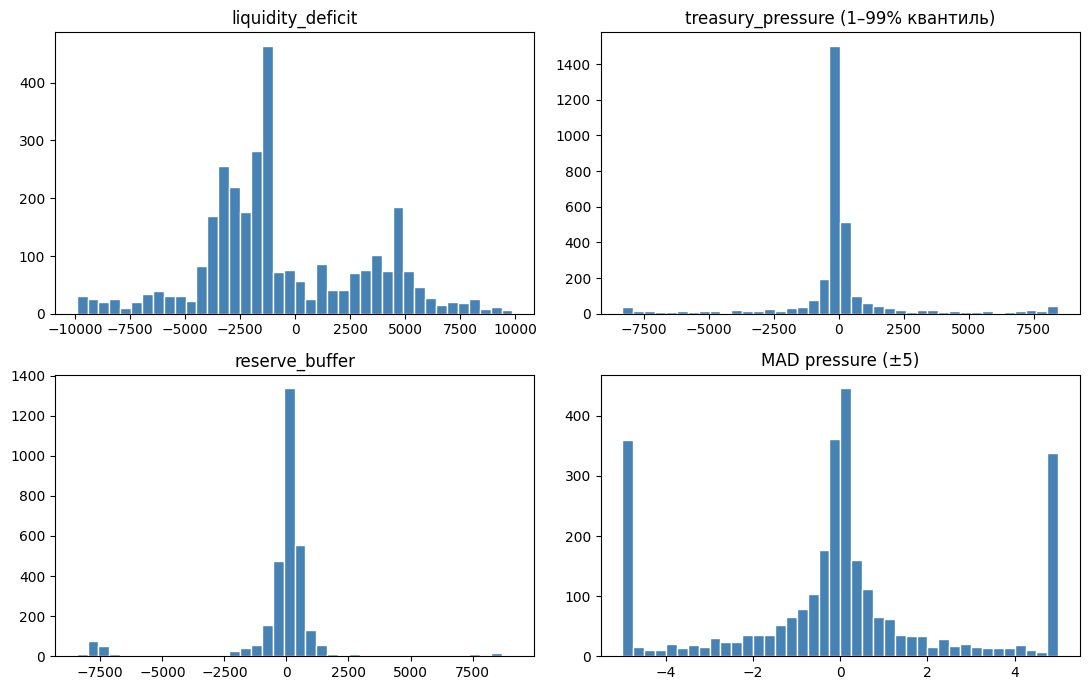

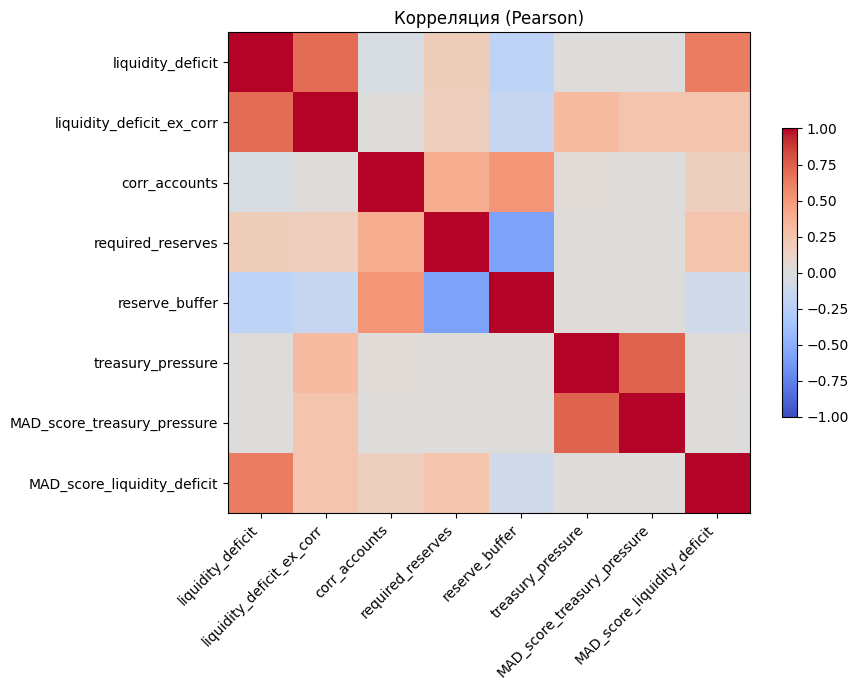

In [6]:
print(m5_df.info())
print("\nПериод:", m5_df["date"].min().date(), "—", m5_df["date"].max().date())
num = m5_df.select_dtypes(include=[np.number]).columns
print("\nПропуски (% строк):")
print((m5_df[num].isna().mean() * 100).round(2).sort_values(ascending=False))

core = [
    "liquidity_deficit",
    "liquidity_deficit_ex_corr",
    "corr_accounts",
    "required_reserves",
    "reserve_buffer",
    "treasury_pressure",
    "MAD_score_treasury_pressure",
    "MAD_score_liquidity_deficit",
]
avail = [c for c in core if c in m5_df.columns]
display(m5_df[avail].describe().T)

print("\nСтресс-флаг по годам:")
print(m5_df.assign(y=m5_df["date"].dt.year).groupby("y")["flag_stress"].agg(["sum", "mean"]).round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

def _hist(ax, series, title):
    s = series.dropna()
    ax.hist(s, bins=min(40, max(15, len(s) // 50)), color="steelblue", edgecolor="white")
    ax.set_title(title)

if "liquidity_deficit" in m5_df.columns:
    _hist(axes[0], m5_df["liquidity_deficit"], "liquidity_deficit")
if "treasury_pressure" in m5_df.columns:
    _tp = m5_df["treasury_pressure"].dropna()
    _lo, _hi = _tp.quantile(0.01), _tp.quantile(0.99)
    _hist(axes[1], _tp.clip(_lo, _hi), "treasury_pressure (1–99% квантиль)")
if "reserve_buffer" in m5_df.columns:
    _hist(axes[2], m5_df["reserve_buffer"], "reserve_buffer")
if "MAD_score_treasury_pressure" in m5_df.columns:
    _hist(axes[3], m5_df["MAD_score_treasury_pressure"].clip(-5, 5), "MAD pressure (±5)")
plt.tight_layout()
plt.show()

if len(avail) >= 3:
    cm = m5_df[avail].corr(numeric_only=True)
    fig2, ax2 = plt.subplots(figsize=(9, 7))
    im = ax2.imshow(cm, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax2, shrink=0.6)
    ax2.set_xticks(range(len(cm.columns)))
    ax2.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax2.set_yticks(range(len(cm.columns)))
    ax2.set_yticklabels(cm.columns)
    ax2.set_title("Корреляция (Pearson)")
    plt.tight_layout()
    plt.show()

**Интерпретация: распределения и корреляции (M5)**

Четыре гистограммы задают «форму данных» для ликвидности. **Дефицит ликвидности** обычно сосредоточен вокруг типичного уровня; длинные хвосты означают редкие, но сильные отклонения. **Treasury pressure** (обрезанный по 1–99% квантилям) показывает типичный масштаб дневного изменения давления без доминирования единичных выбросов — если распределение сильно скошено, дневные изменения асимметричны. **Буфер резервов** (корсчета минус обязательные резервы): смещение в отрицательную сторону соответствует более жёсткому положению банков относительно норматива. **MAD-скор по давлению** (усечённый ±5) показывает, насколько часто текущее изменение выбивается из многолетней «нормы»; толстые хвосты ⇒ чувствительность ряда к шокам.

Матрица корреляций связывает уровни дефицита, буфер, дневное давление и MAD. Сильная положительная связь дефицита с буфером/корсчетами ожидаема как общий масштаб баланса; высокая корреляция двух MAD или двух уровневых рядов может указывать на избыточность признаков при моделировании.

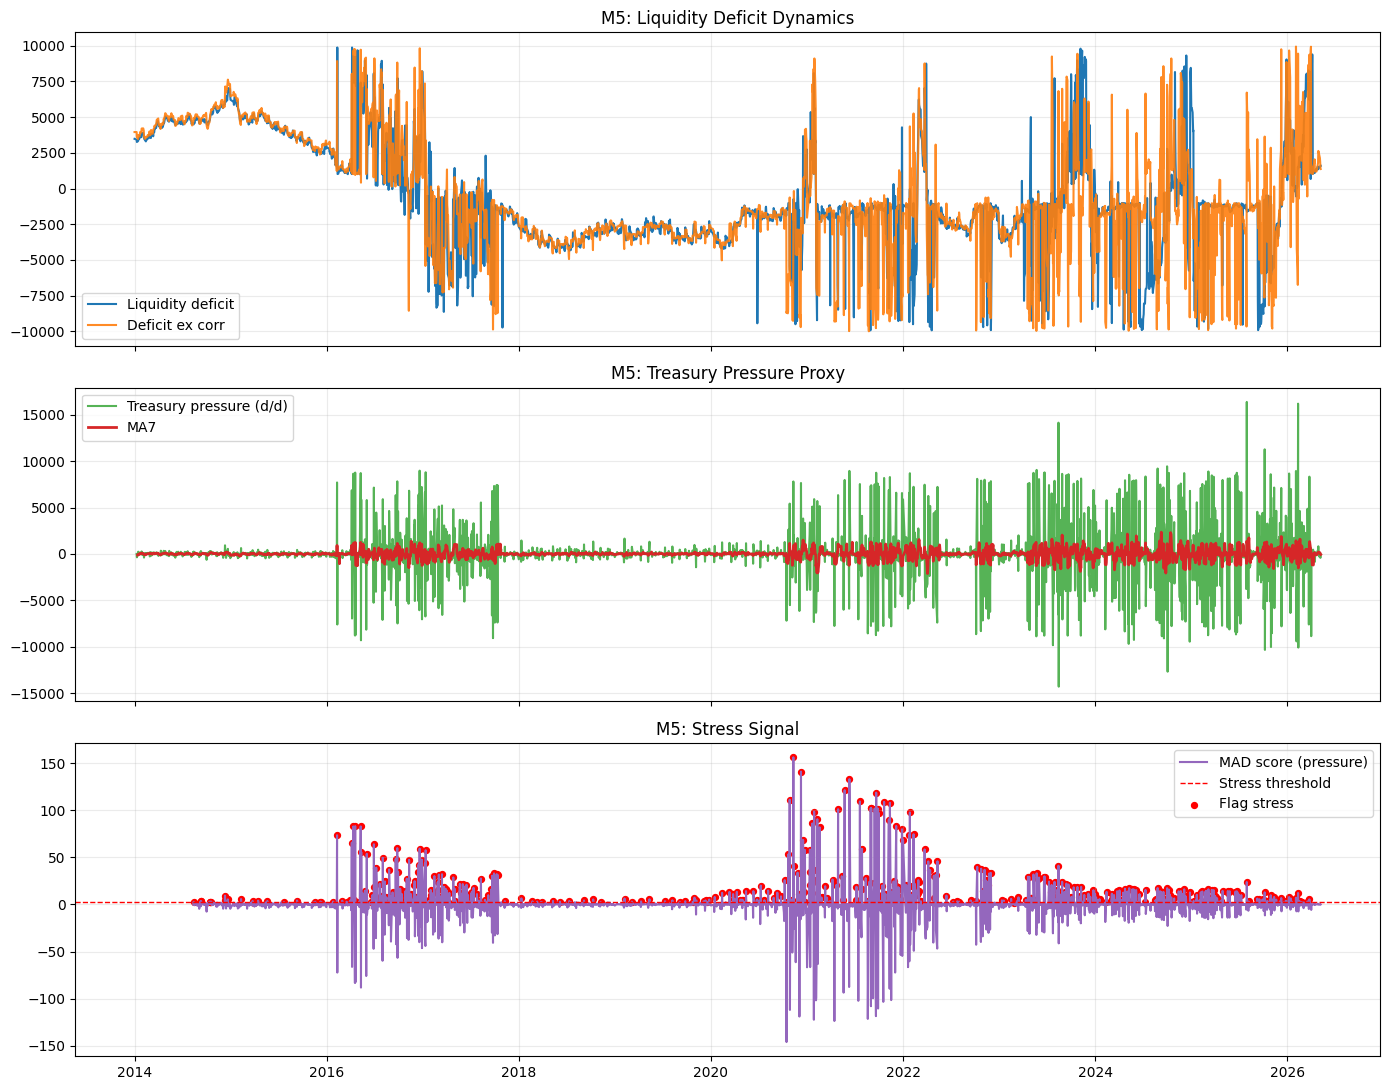

In [7]:
# ????????????
plot_m5(m5_df, out_file='outputs/m5/m5_dashboard.png')


**Интерпретация: панельный дашборд M5**

**Верхняя панель:** совмещение полного дефицита и дефицита без учёта корсчетов показывает, насколько сглаживает картину ликвидность на корреспондентских счетах: большое расхождение линий означает существенный вклад корсчетов в нетто-позицию.

**Средняя панель:** дневное изменение дефицита (без корр.) и скользящее среднее за 7 дней отделяет краткосрочный шум от устойчивого ухудшения/улучшения: серия положительных значений давления при растущем дефиците читается как нарастающее давление на казначейство/ликвидность.

**Нижняя панель:** MAD-скор и порог 2.5 + отметки `flag_stress` выделяют дни, где изменение давления статистически экстремально на фоне ~3 лет истории. Точки стресса, сгруппированные во времени, указывают на эпизоды, а не на разовые глюки данных.

In [8]:
# ?????????? ???????
Path('outputs/m5').mkdir(parents=True, exist_ok=True)
m5_df.to_csv('outputs/m5/m5_dataset.csv', index=False, encoding='utf-8-sig')

print('Rows:', len(m5_df))
print('Date range:', m5_df['date'].min(), '->', m5_df['date'].max())
print('Stress flags:', int(m5_df['flag_stress'].sum()))
print('Saved: outputs/m5/m5_dataset.csv')
print('Saved: outputs/m5/m5_dashboard.png')


Rows: 3095
Date range: 2014-01-01 00:00:00 -> 2026-05-08 00:00:00
Stress flags: 472
Saved: outputs/m5/m5_dataset.csv
Saved: outputs/m5/m5_dashboard.png
